1. # Practical 2 report: from relationships to predictive models

**Student:** Oleh Kovalyshyn

**Date:** 17 Sep 2026

**Practical:** 2 - Regression and evaluation


In [38]:
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, GammaRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

RANDOM=42


In [2]:
diabetes = load_diabetes(as_frame=True)

diabetes_df = diabetes.frame.copy()
diabetes_df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
diabetes_df.shape


(442, 11)

In [4]:
diabetes_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


## 2. Data-preparation readiness

Complete the checklist before describing modelling results. Tick an item only after checking the data or documenting a justified decision.

### Scientific purpose and provenance

- [x] Is the biological question and prediction task stated clearly?
- [x] Is the unit of observation clear?
- [x] Do I know where the data came from, how they were generated, and under which access conditions they may be used?
- [x] Have I recorded the data version, processing history, and transformations already applied?

Dataset Description: [scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset)


### Table shape and identifiers

- [x] Is the table tidy: one observation per row, one variable per column, and one value per cell?
- [x] If needed, have I transposed the original assay into the format expected by the analysis tool?
- [x] Are row names, column names, and identifiers clear, unique, and stable?
- [x] Can every feature and observation be traced to its source?
- [x] Are the feature matrix and metadata aligned by an explicit identifier rather than row order?

The dataset is tidy and pre-processed by scikit. There are no patient identifiers and RangeIndex is used instead

### Types, values, and measurement meaning

- [x] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
- [x] Are units, scales, encodings, reference categories, and detection limits understood?
- [x] Have impossible values, inconsistent labels, unexpected categories, constant features, and extreme values been checked?
- [x] Are normalization, scaling, log transformation, and batch-correction steps documented?

All columns are `float64`, no missing values. Sex is categorical value but is also represented as `float64` (one of the two values) and subjected to mean-centralization and standard deviation scaling. In the original description, values 1 and 2 are used to denote sex but there's no mention of which one is male and which is female. Age has been normalized as well, and there is no mention about the age range. It can be recovered from the original, non-normalized dataset:

In [5]:
original = pd.read_csv("https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt", sep="\t")
original['AGE'].describe()


count    442.000000
mean      48.518100
std       13.109028
min       19.000000
25%       38.250000
50%       50.000000
75%       59.000000
max       79.000000
Name: AGE, dtype: float64

### Missing values

- [x] Have missing values been detected using all representations, not only `NaN`?
- [x] Have missing values been measured by row, column, and relevant group?
- [x] Do I know whether missingness is structural, technical, or plausibly related to biology or the target?
- [x] Have retention, removal, or imputation been justified?
- [x] If imputing, will the imputer be fitted on training data only?

No missing values

### Replicates, dependence, and grouping

- [x] Have exact and near-duplicate observations been checked?
- [x] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [x] Is the independent biological unit identified by a grouping variable?
- [x] Will related observations remain in the same train/validation/test split?
- [x] Is the provenance of synthetic or augmented observations recorded?

Every sample is a separate patient, making them all different biological replicates. There are no related or synthetic observations declared.

### Target, leakage, confounding, and reproducibility

- [x] Is the target defined before modelling?
- [x] Have identifiers, post-outcome variables, duplicated target information, and other leakage sources been excluded?
- [x] Have batch, site, subject, treatment, sex, age, time, and other possible confounders been considered?
- [x] Does the planned split represent the biological generalization question?
- [x] Are random seeds, software versions, file names, shapes, and preprocessing decisions recorded?

**Preparation summary:**

- Biological unit: patient
- Number of observations and features: 442 observations, 11 features
- Target and feature definition: Target is quantitative measure of disease progression one year after baseline, features are age, sex, bmi, blood pressure and blood composition data
- Missing-value decision: No NAs
- Replicate/grouping decision: Random split, all samples independent
- Main confounder or leakage source: -
- Train/test split and justification: Random split, 25% test, 75% train
- Remaining concerns: -

## 3 Your  task: Diabetes regression

### 3.1 Data presentation

Identify:

- one observation - a patient;
- the target variable - disease progression level;
- predictor variables - age, sex, bmi, bp, s1-s6;
- dimensionality of the dataset - 11 dimensions;
- whether the predictors and target have physical units or transformed scales - all values are mean-centered and sd-scaled.

### 3.2 Descriptive analysis

- Summarize the target.
- Visualize its distribution.
- Visualize at least three predictor-target relationships.
- State the biological or predictive question addressed by each plot.

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

/var/folders/m7/qn99csmd48s9232z_r7d50nw0000gn/T/ipykernel_77059/1963734970.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


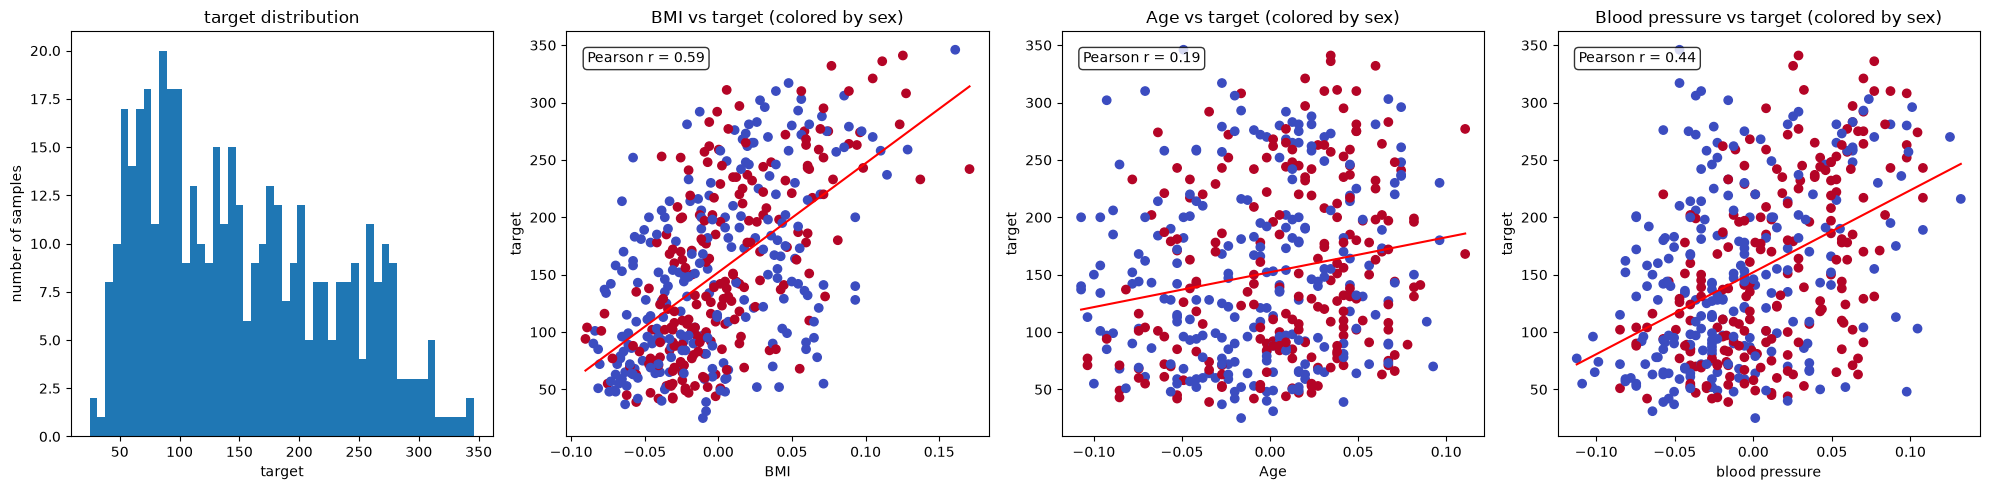

In [6]:
display(diabetes_df['target'].describe())

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

axs[0].hist(diabetes_df['target'], bins=50)
axs[0].set_title('target distribution')
axs[0].set_xlabel('target')
axs[0].set_ylabel('number of samples')

r = diabetes_df['bmi'].corr(diabetes_df['target'])
axs[1].scatter(diabetes_df['bmi'], diabetes_df['target'], c=diabetes_df['sex'], cmap='coolwarm')
axs[1].set_title('BMI vs target (colored by sex)')
axs[1].set_xlabel('BMI')
axs[1].set_ylabel('target')
axs[1].text(0.05, 0.95, f'Pearson r = {r:.2f}',
            transform=axs[1].transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

m, b = np.polyfit(diabetes_df['bmi'], diabetes_df['target'], 1)
x = np.sort(diabetes_df['bmi'])
axs[1].plot(x, m * x + b, color='red')

r = diabetes_df['age'].corr(diabetes_df['target'])
axs[2].scatter(diabetes_df['age'], diabetes_df['target'], c=diabetes_df['sex'], cmap='coolwarm')
axs[2].set_title('Age vs target (colored by sex)')
axs[2].set_xlabel('Age')
axs[2].set_ylabel('target')
axs[2].text(0.05, 0.95, f'Pearson r = {r:.2f}',
            transform=axs[2].transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

m, b = np.polyfit(diabetes_df['age'], diabetes_df['target'], 1)
x = np.sort(diabetes_df['age'])
axs[2].plot(x, m * x + b, color='red')

r = diabetes_df['bp'].corr(diabetes_df['target'])
axs[3].scatter(diabetes_df['bp'], diabetes_df['target'], c=diabetes_df['sex'], cmap='coolwarm')
axs[3].set_title('Blood pressure vs target (colored by sex)')
axs[3].set_xlabel('blood pressure')
axs[3].set_ylabel('target')
axs[3].text(0.05, 0.95, f'Pearson r = {r:.2f}',
            transform=axs[3].transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

m, b = np.polyfit(diabetes_df['bp'], diabetes_df['target'], 1)
x = np.sort(diabetes_df['bp'])
axs[3].plot(x, m * x + b, color='red')

fig.tight_layout()
fig.show()


We see that the target distribution is heavy-tailed. Most of the patients have onset or early stage diabetes. BMI heavily correlates with target (r=0.59), so does blood pressure (r=0.44), as expected. Interestingly enough, age doesn't show that strong correlation. In fact, correlation between age and target is the same as between age and BMI. BMI is expected to grow-then-decline (U shape) with age ([Yang, Walsh, Johnson, Harris, 2021](https://www.pnas.org/doi/10.1073/pnas.2020167118)) - a pattern that we don't observe in this dataset, suggesting it it isn't population-representative. At the same time, correlations with BMI and blood pressure are expected and well established ([Gray, Picone, Sloan, Yashkin, 2015](https://pubmed.ncbi.nlm.nih.gov/25580754/); [Przezak, Bielka, Pawlik, 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9224227/)).

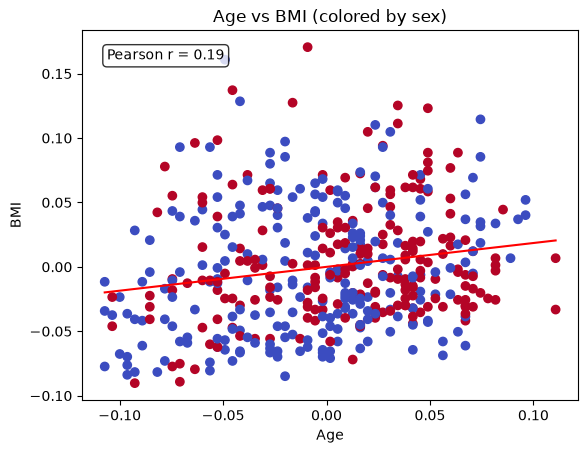

In [7]:
r = diabetes_df['age'].corr(diabetes_df['bmi'])
plt.scatter(diabetes_df['age'], diabetes_df['bmi'], c=diabetes_df['sex'], cmap='coolwarm')
plt.title('Age vs BMI (colored by sex)')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.text(0.05, 0.95, f'Pearson r = {r:.2f}',
         transform=plt.gca().transAxes, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

m, b = np.polyfit(diabetes_df['age'], diabetes_df['bmi'], 1)
x = np.sort(diabetes_df['age'])
plt.plot(x, m * x + b, color='red')
plt.show()


### 3.3 Correlation

- Calculate correlation using ar least 2 different methods.
- Identify the predictor most strongly correlated with the target.
- Compare results.
- Explain why correlation is not sufficient for feature selection or causal interpretation.

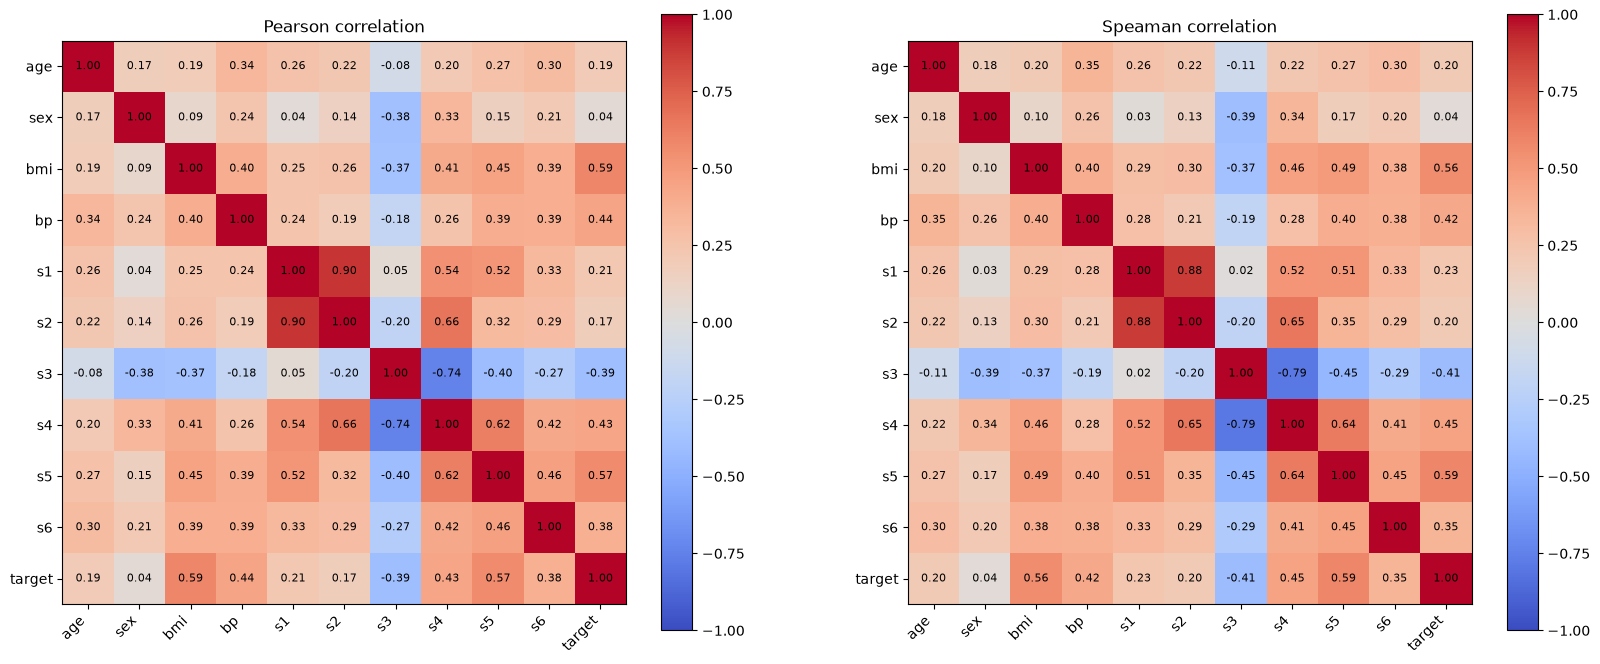

In [8]:
def visualize_correlations(corr, fig, ax, title=""):
  im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
  ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
  ax.set_yticks(range(len(corr)), corr.columns)

  if title:
    ax.set_title(title)

  for i in range(len(corr)):
    for j in range(len(corr)):
      ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

  fig.colorbar(im)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

visualize_correlations(diabetes_df.corr(method="pearson"), fig, ax[0], title="Pearson correlation")
visualize_correlations(diabetes_df.corr(method="spearman"), fig, ax[1], title="Speaman correlation")

plt.show()


Correlation matrices are largely the same, with Spearman showing stronger correlation between s5 and target than between bmi and target, compared to Pearson.

There are a quite a lot of good proxy variables, e.g. s1 strongly correlates with s2, and s3 reverse-correlates with s4. Sex is never a good predictor for target or another features.

Correlation can provide a good instinct of trend, but it doesn't explain disease progress ideally. Moreso, it can be not causal. Blood pressure is associated with diabetes, but it can be more likely caused by lifestyle (overeating increasing BMI, causing hypertension and diabetes).

### 4.4 Simple regression

Choose one predictor and fit a simple linear regression. Report and interpret:

- intercept;
- slope;
- the scale of the predictor;
- whether the slope is a causal effect.

In [9]:
X = diabetes_df[["bmi"]]
y = diabetes_df["target"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


Intercept: 152.13348416289617
Slope: 949.4352603840388


### 4.5 Residual diagnostics

Produce:

- observed versus predicted plot;
- residuals versus fitted plot;
- residual histogram;
- Q-Q plot.

Discuss linearity, homoscedasticity, residual normality, unusual observations, and any limitations of the diagnostics.

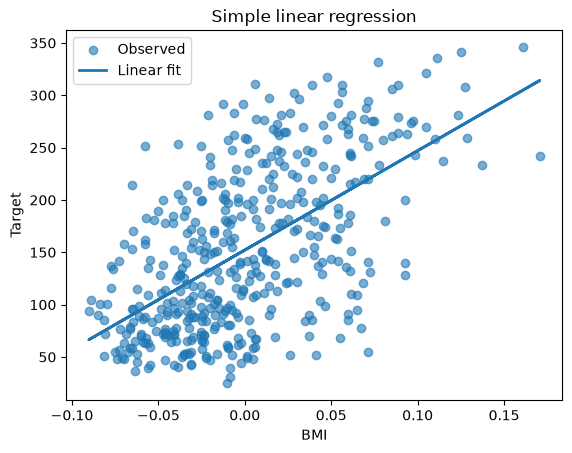

In [10]:
y_hat = model.predict(X)

plt.scatter(X, y, alpha=0.6, label="Observed")

plt.plot(X, y_hat, linewidth=2, label="Linear fit")

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Simple linear regression")
plt.legend()
plt.show()


In [11]:
residuals = y.to_numpy() - y_hat

residual_df = pd.DataFrame({
    "observed": y.to_numpy(),
    "predicted": y_hat,
    "residual": residuals})

residual_df.head()


,observed,predicted,residual
0,151.0,210.710038,-59.710038
1,75.0,103.262195,-28.262195
2,141.0,194.337033,-53.337033
3,206.0,141.124769,64.875231
4,135.0,117.588574,17.411426


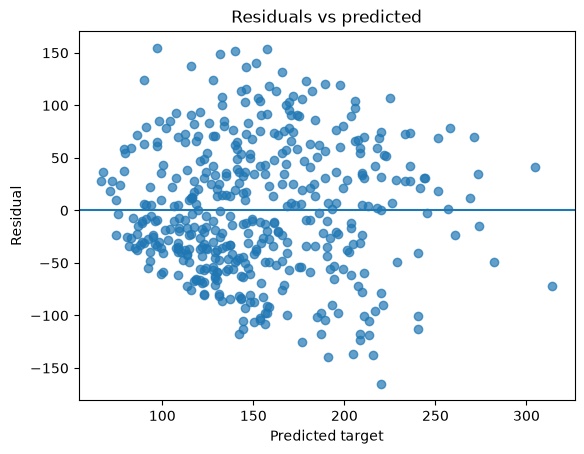

In [12]:
plt.scatter(
    residual_df["predicted"],
    residual_df["residual"],
    alpha=0.7)

plt.axhline(0)
plt.xlabel("Predicted target")
plt.ylabel("Residual")
plt.title("Residuals vs predicted")
plt.show()


,observed,predicted,residual
count,442.000000,442.000000,4.420000e+02
mean,152.133484,152.133484,-2.623542e-14
std,77.093005,45.211203,6.244420e+01
min,25.000000,66.422935,-1.649199e+02
25%,87.000000,119.635200,-4.357231e+01
50%,140.500000,145.218020,-8.649306e+00
75%,211.500000,181.801452,4.634425e+01
max,346.000000,314.064630,1.548777e+02


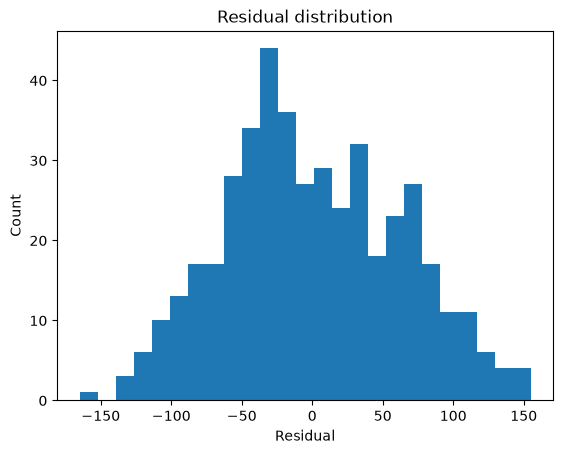

In [13]:
display(residual_df.describe())

plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.show()


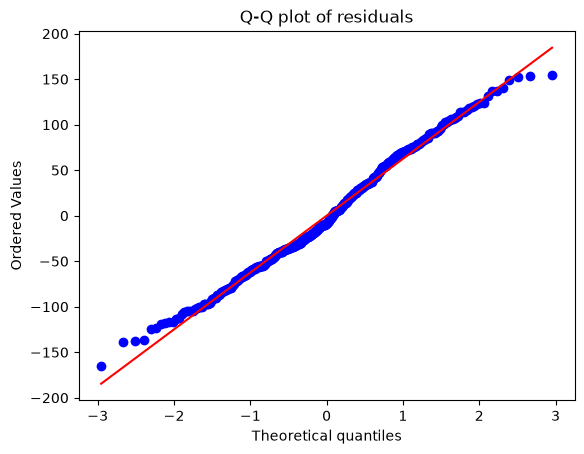

In [14]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot of residuals")
plt.show()


BMI is a fairly good predictor for disease progression. With that said, this dependency is **not** directly causal. While overeating is indeed one of the causes of Type 2 Diabetes, it alone cannot be used for diagnostics. In addition, the BMI data are not homogenous. The distribution is more left-leaning, having less overweight patients. The resulting predictions show some sights of heteroskedasticity, but overall look evenly distributed. Residuals look normal and slightly deviate from the ideal normal distribution on the Q-Q plot.

### 4.6 Multiple regression and multicollinearity

Fit a model using all available predictors. Inspect:

- coefficients;
- predictor correlations;
- possible multicollinearity;
- whether standardized predictors change coefficient interpretation.

In [21]:
diabetes_df.columns[:-1]

X = diabetes_df[diabetes_df.columns[:-1]]
y = diabetes_df["target"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
coef_table = pd.DataFrame({"feature": X.columns, "coefficient": model.coef_})
coef_table

Intercept: 152.13348416289597


,feature,coefficient
0,age,-10.009866
1,sex,-239.815644
2,bmi,519.845920
3,bp,324.384646
4,s1,-792.175639
5,s2,476.739021
6,s3,101.043268
7,s4,177.063238
8,s5,751.273700
9,s6,67.626692


### 4.7 Train/test evaluation

Create a justified train/test split and report MAE, MSE, RMSE, and $R^2$. Compare simple and multiple regression on test data.

Explain whether the split answers the intended biological or clinical generalization question.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=RANDOM,
)

def regression_metrics(y_true, y_pred):
  return {
    "MAE": mean_absolute_error(y_true, y_pred),
    "MSE": mean_squared_error(y_true, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    "R2": r2_score(y_true, y_pred)
  }

In [35]:
results = []

# Model 1: BMI only
m1 = LinearRegression()
m1.fit(X_train[["bmi"]], y_train)

for split_name, X_split, y_split in [
  ("train", X_train, y_train),
  ("test", X_test, y_test)
]:
  pred = m1.predict(X_split[["bmi"]])
  metrics = regression_metrics(y_split, pred)
  results.append({
    "model": "Simple Linear Regression",
    "split": split_name,
    **metrics
  })

metrics

{'MAE': 52.25997644534553,
 'MSE': 4061.8259284949268,
 'RMSE': np.float64(63.73245584860925),
 'R2': 0.23335039815872138}

In [47]:
# Model 2: Multiple regression (all predictors)
m2 = LinearRegression()
m2.fit(X_train, y_train)

for split_name, X_split, y_split in [
  ("train", X_train, y_train),
  ("test", X_test, y_test)
]:
  pred = m2.predict(X_split)
  metrics = regression_metrics(y_split, pred)
  results.append({
    "model": "Multiple Linear Regression",
    "split": split_name,
    **metrics
  })

metrics

{'MAE': 42.79409467959994,
 'MSE': 2900.193628493482,
 'RMSE': np.float64(53.85344583676593),
 'R2': 0.45260276297191937}

In [39]:
# Model 3: Gamma regression (all predictors)
m3 = GammaRegressor(alpha=0)
m3.fit(X_train, y_train)

for split_name, X_split, y_split in [
  ("train", X_train, y_train),
  ("test", X_test, y_test)
]:
  pred = m3.predict(X_split)
  metrics = regression_metrics(y_split, pred)
  results.append({
    "model": "Gamma GML (log-link)",
    "split": split_name,
    **metrics
  })

metrics

{'MAE': 41.525684541362324,
 'MSE': 2882.4734971009466,
 'RMSE': np.float64(53.68867196253737),
 'R2': 0.45594735033627654}

In [40]:
results_df = pd.DataFrame(results)
results_df

,model,split,MAE,MSE,RMSE,R2
0,Simple Linear Regression,train,51.379728,3854.112652,62.081500,0.365724
1,Simple Linear Regression,test,52.259976,4061.825928,63.732456,0.233350
2,Multiple Linear Regression,train,43.483504,2868.549703,53.558843,0.527919
3,Multiple Linear Regression,test,42.794095,2900.193628,53.853446,0.452603
4,Gamma GML (log-link),train,43.239921,2881.468748,53.679314,0.525793
5,Gamma GML (log-link),test,41.525685,2882.473497,53.688672,0.455947


### 4.8 Independent-task conclusion

Answer:

1. Which model generalized better?
2. Did adding more variables help?
3. Are any regression assumptions questionable?
4. Are coefficient interpretations straightforward?
5. What is one important limitation of the dataset or model?

Remember that the predictors from `load_diabetes()` are already standardized.

Multidimensional models (`m2`, `m3`) generalized better as they had access to more information than the simple regression model (`m1`). With that said, given the high redundancy in data (many covariates correlating), introducing more variables had limited impact. Utilizing of a GLM model yielded basically the same results as the multilinear model.

The resulting models are more or less interpretable. At the same time, it's interesting that the slope for `sex` if so different from zero. While biologically it shouldn't be so important for the task. It probably hints at some imbalances in the data. With that said, the removal of `sex` from the training data did not influence the performance much.

Many of the covariates have direct biological meaning, as described with age, bmi and blood pressure previously. With that said, "diabetes" is a vague term. Type 1 and type 2 diabetes differ a lot. "Disease progression" target hints at type 2 diabetes, but this can pose a limitation in the dataset, if there are some type 1 data mixed in.